# Value at Risk (VaR) 99% on an FX Exposure Book — Parametric vs. Monte Carlo

**Context.** This notebook is a practical, self-contained exercise in market risk quantification. This exercise
 measures how much a treasury's unhedged foreign-currency exposures could
lose in adverse market moves, and using that measure to size hedges (FX forwards, options) and report risk
to management.

**Goal.** Given a small book of FX exposures, compute the **1-day 99% Value at Risk (VaR99)** using two
standard approaches:

1. **Parametric / Variance-Covariance (delta-normal) VaR**
2. **Monte Carlo VaR**

and then **backtest** the resulting model with the Kupiec Proportion-of-Failures (POF) test, to show the
result is not just a number but something that can be validated.

The two methods will be compared, and the notebook closes with a short discussion of VaR's assumptions and
limitations — a point that tends to come up directly in risk interviews.

## 1. What is VaR?

**Value at Risk at confidence level $\alpha$** is the loss level that, over a given time horizon, will not
be exceeded with probability $\alpha$ under normal market conditions. In other words, it is the maximum loss
with probability $\alpha$. It is usually represented as a monentary value or a percentage:

$$
P(\, \Delta V < -\text{VaR}_\alpha \,) = 1 - \alpha
$$

where $\Delta V$ is the change in portfolio value over the horizon (can be positive for gains, negative for losses). VaR is a
positive number that represents a loss. For $\alpha = 99\%$, we expect the
actual loss to exceed the VaR estimate on roughly **1 out of every 100 days**, if the model is well
calibrated.

Apart from the use of historical data, there are two ways to arrive at that number:

| Method | Idea                                                                                                                                                                                              | Key assumption                                                                                |
|---|---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------|-----------------------------------------------------------------------------------------------|
| **Parametric (Variance-Covariance)** | Assume returns are normally distributed, get VaR directly in closed form from the covariance matrix. It requires an estimate of 2 factors: an expected return, and an expected standard deviation | Linear portfolio, normally distributed returns                                                |
| **Monte Carlo** | Simulate thousands of possible return scenarios from the estimated distribution, revalue the portfolio in each, read the loss off the simulated distribution                                      | Same distributional assumption here, but the machinery extends to non-linear/non-normal cases |

Both are compared against actual historical outcomes via **backtesting** in Section 8.

## 2. Data source

**Source: [Yahoo Finance](https://finance.yahoo.com/) via the `yfinance` package.** It requires no API key
or registration, gives free daily FX history, and keeps this notebook fully reproducible — anyone can
re-run it and pull fresh data. For a quick, credible risk prototype this is the standard choice.

We use three major USD-quoted FX pairs, ~3 years of daily closes:

- `EURUSD=X` — USD per 1 EUR
- `GBPUSD=X` — USD per 1 GBP
- `USDJPY=X` — JPY per 1 USD (note the inverted quoting convention vs. the other two — handled explicitly in Section 3)

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
from scipy.stats import norm, chi2

plt.rcParams["figure.figsize"] = (10, 4)
np.random.seed(42)

market_days = 252  # approx. number of trading days in a year, used to annualise daily volatility

In [3]:
tickers = ["EURUSD=X", "GBPUSD=X", "USDJPY=X"]

end_date = pd.Timestamp.today().normalize()
start_date = end_date - pd.DateOffset(years=3)

# Downloaded one ticker at a time (more robust than a single multi-ticker call with yfinance)
series = {
    t: yf.download(t, start=start_date, end=end_date, auto_adjust=True, progress=False)["Close"][t]
    for t in tickers
}
prices = pd.DataFrame(series).dropna()
prices.columns = ["EURUSD", "GBPUSD", "USDJPY"]

print(f"{len(prices)} daily observations, {prices.index[0].date()} to {prices.index[-1].date()}")
prices.tail()

778 daily observations, 2023-08-30 to 2026-08-28


,EURUSD,GBPUSD,USDJPY
Date,,,
2026-08-24,1.168156,1.365355,158.904007
2026-08-25,1.166834,1.363829,159.139008
2026-08-26,1.167474,1.364703,159.223007
2026-08-27,1.165488,1.359693,159.255005
2026-08-28,1.165637,1.359712,159.320999


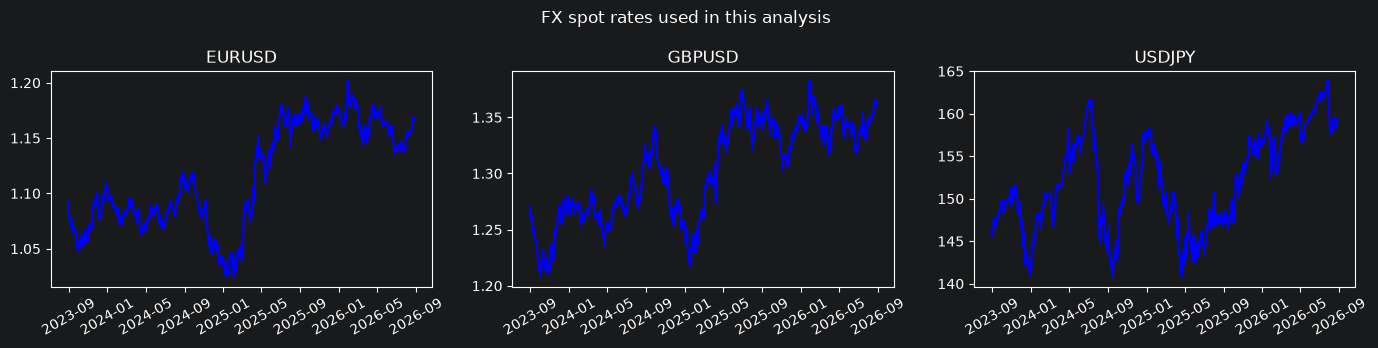

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(14, 3.5))
for ax, col in zip(axes, prices.columns):
    ax.plot(prices.index, prices[col], color="b")
    ax.set_title(col)
    ax.tick_params(axis="x", rotation=30)
fig.suptitle("FX spot rates used in this analysis")
fig.tight_layout()
plt.show()

## 3. A hypothetical FX exposure book

In practice, a corporate treasury's FX risk comes from **unhedged receivables and payables** in foreign
currency generated by commercial operations (an EUR sale not yet collected, a JPY purchase not yet paid,
etc.). We define a small illustrative book, expressed in the **reporting/base currency: USD**:

| Exposure | Notional | Nature | Direction |
|---|---|---|---|
| EUR | 10,000,000 | Trade receivable | Long EUR (asset) |
| GBP | 6,000,000 | Trade receivable | Long GBP (asset) |
| JPY | 500,000,000 | Trade payable | Short JPY (liability) |

**Sign convention.** `EURUSD` and `GBPUSD` already quote USD per unit of foreign currency, so a long
position has a *positive* dollar exposure to their returns. `USDJPY` is quoted the other way around (JPY
per USD): if the JPY liability must be settled later and **USDJPY rises** (USD strengthens / JPY weakens),
the USD cost of paying it *falls* — a gain. So the JPY payable's dollar exposure enters with a **positive**
sign on `USDJPY` returns as well, once expressed correctly.

In [5]:
spot = prices.iloc[-1]

notional_eur = 10_000_000   # long EUR receivable
notional_gbp = 6_000_000    # long GBP receivable
notional_jpy = 500_000_000  # short JPY payable

exposures = pd.Series({
    "EURUSD": notional_eur * spot["EURUSD"],           # long EUR -> long EURUSD
    "GBPUSD": notional_gbp * spot["GBPUSD"],            # long GBP -> long GBPUSD
    "USDJPY": notional_jpy / spot["USDJPY"],            # short JPY payable -> long USDJPY (see note above)
}, name="USD exposure")

e = exposures.values  # dollar-delta vector, one entry per FX rate

display_df = exposures.to_frame()
display_df["% of gross exposure"] = 100 * display_df["USD exposure"] / display_df["USD exposure"].abs().sum()
display_df

,USD exposure,% of gross exposure
EURUSD,1.165637e+07,50.783738
GBPUSD,8.158270e+06,35.543435
USDJPY,3.138318e+06,13.672827


## 4. Returns

**We work with daily log returns, $r_t = \ln(P_t / P_{t-1})$** (where $t$ is time and $P$ is the price or
pair value), **instead of simple percentage returns.** The reason is symmetry, and it matters because the
parametric method (Section 5) assumes returns follow a normal distribution — a perfectly symmetric bell
curve.

**Simple % returns are not symmetric.** A +10% move followed by a -10% move does **not** bring you back to
where you started. As a result, the distribution of simple returns is naturally a bit skewed, not perfectly centered
around zero. Log returns fix this.

A log return of $+x$ and one of $-x$ are true opposites and exactly cancel out. A gain and
a loss of the same size are mirror images of each other, which is exactly what "symmetric around zero" means.

Because log returns are symmetric and the normal distribution is symmetric by construction, using log
returns makes the normality assumption behind the parametric VaR formula more internally consistent. For the
small daily moves typical of FX, log returns and simple % returns are numerically almost identical anyway —
so this choice barely changes the actual numbers, it just fits the assumption a bit more cleanly.

In [6]:
returns = np.log(prices / prices.shift(1)).dropna()

print("Annualised volatility (%):")
print((returns.std() * np.sqrt(market_days) * 100).round(2)) # Applying square root of time (scale the std through time)

print("\nCorrelation matrix:")
returns.corr().round(2)

Annualised volatility (%):
EURUSD    6.80
GBPUSD    6.93
USDJPY    9.29
dtype: float64

Correlation matrix:


,EURUSD,GBPUSD,USDJPY
EURUSD,1.00,0.82,-0.56
GBPUSD,0.82,1.00,-0.49
USDJPY,-0.56,-0.49,1.00


## 5. Method 1 — Parametric (Variance-Covariance) VaR

**The idea, in plain terms.** Assume the portfolio's daily gain/loss follows a normal (bell-curve)
distribution. A normal distribution is fully described by just two numbers: its **mean** (the average daily
return — over a single day this is tiny compared to the day-to-day swings, so we simply set it to 0) and its
**standard deviation**, i.e. its volatility (how much the daily P&L typically moves up or down). Once we know
that volatility, VaR is just "how far into the loss tail of that bell curve do I need to go so that only 1%
of outcomes are worse" — a single formula, no simulation required.

**For a single position**, that is:

$$
\text{VaR}_\alpha = z_\alpha \cdot \sigma
$$

where $\sigma$ is that position's daily volatility (in USD) and $z_\alpha$ is the number of standard
deviations needed to cut off $1-\alpha$ of the normal curve's area ($z_{0.99} \approx 2.33$).

**For the whole portfolio**, the daily P&L is just each exposure times its own return, summed up:

$$
\Delta V = \mathbf{e}^\top \mathbf{r} = e_{\text{EUR}} \, r_{\text{EUR}} + e_{\text{GBP}} \, r_{\text{GBP}} + e_{\text{JPY}} \, r_{\text{JPY}}
$$

using the exposures $\mathbf{e}$ from Section 3 and the returns $\mathbf{r}$ from Section 4. This is the
relationship we reuse in Section 6. Its volatility $\sigma_p$ is what we need for the VaR formula above —
which is where the covariance matrix comes in.

**Why "covariance"?** Our book holds *three* currencies, each with its own volatility, that also move
together: EUR and GBP tend to rise/fall together against USD, while JPY tends to move the opposite way (see
the correlation matrix in Section 4). So the portfolio's overall volatility is **not** just the sum of the
three individual volatilities — it depends on how correlated they are: opposite moves partly cancel out
(diversification), while moving together amplifies the swing. The **covariance matrix** $\Sigma$ captures
exactly that: each currency's own variance on the diagonal, and how every pair of currencies moves together
off the diagonal.

Combining the exposures $\mathbf{e}$ (Section 3) with $\Sigma$ gives the portfolio's volatility:

$$
\sigma_p = \sqrt{\mathbf{e}^\top \Sigma \, \mathbf{e}}
$$

And finally, the same one-line formula as for a single asset:

$$
\text{VaR}_{99} = z_{0.99} \cdot \sigma_p
$$

That is the whole method: no simulation, one closed-form formula, built from the exposures and the
historical covariance matrix of returns.

*(Implementation note: we plug in daily log returns, computed in Section 4, as our measure of "return" —
this is a standard, minor convention for computing volatility, not something specific to this method; simple
percentage returns would give practically the same answer over daily FX moves this small.)*

In [7]:
Sigma = returns.cov().values  # daily covariance matrix of log returns

sigma_p = np.sqrt(e @ Sigma @ e)  # portfolio daily P&L volatility, in USD

z_99 = norm.ppf(0.99)
var_parametric = z_99 * sigma_p

gross_exposure = np.abs(e).sum()
print(f"Portfolio daily P&L volatility: ${sigma_p:,.0f}")
print(f"z_0.99 = {z_99:.4f}")
print(f"Parametric 1-day VaR99: ${var_parametric:,.0f}  "
      f"({100 * var_parametric / gross_exposure:.2f}% of gross exposure)")

Portfolio daily P&L volatility: $72,948
z_0.99 = 2.3263
Parametric 1-day VaR99: $169,703  (0.74% of gross exposure)


## 6. Method 2 — Monte Carlo VaR

We want the same number as before — the 1-day 99% VaR — but
this time without assuming a closed-form formula. Instead we will build up, empirically, through MonteCarlo simulations, the distribution of
possible portfolio outcomes, and simply read the 99% VaR off it directly:

$$
\text{VaR}_{99} = -\,\text{Percentile}_{1\%}\big(\{\Delta V_k\}_{k=1}^{N}\big)
$$

So the target is a large collection of *simulated* portfolio P&L outcomes, $\{\Delta V_k\}$. Working
backwards from there:

**To get $\Delta V_k$, I need a simulated return vector $\mathbf{r}_k$.Now we don´t use historical values, so we need to simulate them. ** From Section 5 we already have the
relationship $\Delta V_k = \mathbf{e}^\top \mathbf{r}_k$ — the exposures $\mathbf{e}$ are fixed (Section 3),
so all that is missing is a plausible simulated return vector for each scenario $k$.

**To get a *realistic* $\mathbf{r}_k$, I need it to reproduce the real volatilities and correlations between
the three currencies** — otherwise the simulation would not resemble actual FX behaviour. Those are exactly
the two ingredients already estimated from history in Section 4/5: the covariance matrix $\Sigma$.

**To turn independent random noise into correlated returns that match $\Sigma$, I need the Cholesky
decomposition.** If I just drew three independent random numbers, they would have no correlation between
them — but EUR, GBP and JPY returns are correlated in reality (Section 4). The standard trick to inject the
right correlation structure is: factorise $\Sigma = L L^\top$ (where $L$ is a matrix that "spreads" the
independent noise below into the right volatilities and correlations), draw independent standard-normal
noise $\mathbf{Z} \sim \mathcal{N}(0, I)$ (mean 0, standard deviation $I$, the identity matrix — i.e. each of
the three draws is unit-variance and uncorrelated with the others), and transform it as
$\mathbf{r} = L\,\mathbf{Z}$. The resulting $\mathbf{r}$ has exactly covariance $\Sigma$, by construction.

**Putting the chain together, in the order we now compute it:**

1. Reuse $\Sigma$ (already computed in Section 5) and factorise it: $\Sigma = L L^\top$.
2. Draw a large number $N$ of independent scenarios $\mathbf{Z}_k \sim \mathcal{N}(0, I)$.
3. Transform each into a correlated simulated return vector: $\mathbf{r}_k = L\,\mathbf{Z}_k$.
4. Revalue the portfolio under each scenario: $\Delta V_k = \mathbf{e}^\top \mathbf{r}_k$.
5. Read the 99% VaR off the resulting distribution of $\{\Delta V_k\}$, as in the formula above.

Both methods share the same normal assumption here, so the results should be close — Monte Carlo's real
value shows up once the model is extended beyond this simple linear/normal case (e.g. FX **options** in a
hedging book, or fat-tailed return distributions), where no closed-form parametric formula exists but the
same simulate-then-read-off-the-percentile recipe above still works unchanged.

In [8]:
n_sims = 100_000
L = np.linalg.cholesky(Sigma)

Z = np.random.standard_normal((n_sims, len(e)))
sim_returns = Z @ L.T                 # correlated simulated daily returns
sim_pnl = sim_returns @ e             # simulated portfolio P&L, in USD

var_montecarlo = -np.percentile(sim_pnl, 1)

print(f"Monte Carlo 1-day VaR99 ({n_sims:,} scenarios): ${var_montecarlo:,.0f}  "
      f"({100 * var_montecarlo / gross_exposure:.2f}% of gross exposure)")

Monte Carlo 1-day VaR99 (100,000 scenarios): $169,331  (0.74% of gross exposure)


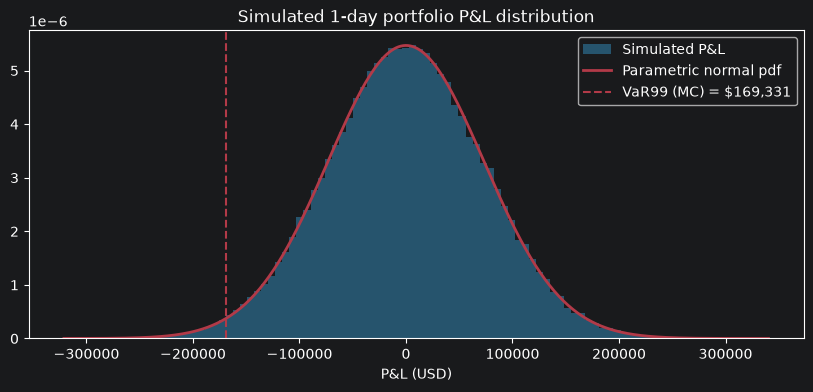

In [9]:
fig, ax = plt.subplots()
ax.hist(sim_pnl, bins=100, density=True, color="#2C6E91", alpha=0.7, label="Simulated P&L")

x = np.linspace(sim_pnl.min(), sim_pnl.max(), 300)
ax.plot(x, norm.pdf(x, 0, sigma_p), color="#B23A48", lw=2, label="Parametric normal pdf")

ax.axvline(-var_montecarlo, color="#B23A48", ls="--", lw=1.5, label=f"VaR99 (MC) = ${var_montecarlo:,.0f}")
ax.set_title("Simulated 1-day portfolio P&L distribution")
ax.set_xlabel("P&L (USD)")
ax.legend()
plt.show()

## 7. Comparing the two methods

In [10]:
comparison = pd.DataFrame({
    "VaR99 (USD)": [var_parametric, var_montecarlo],
    "% of gross exposure": [100 * var_parametric / gross_exposure, 100 * var_montecarlo / gross_exposure],
}, index=["Parametric (Variance-Covariance)", "Monte Carlo"])

comparison.round(2)

,VaR99 (USD),% of gross exposure
Parametric (Variance-Covariance),169703.16,0.74
Monte Carlo,169331.04,0.74


The two figures are close, as expected — both rely on the same normal / linear assumptions, and the small
remaining gap is just Monte Carlo sampling noise (it shrinks as `n_sims` grows). Parametric VaR is faster
and exact under its assumptions; Monte Carlo is slower but generalises directly to non-linear payoffs
(FX options) and non-normal return distributions, which is why both are typically kept in a treasury risk
toolkit rather than just one.

## 8. Backtesting — Kupiec's Proportion-of-Failures (POF) test

**Kupiec's POF test is a statistical test that checks whether the number of VaR exceptions we actually
observe is consistent with the number we would expect if the model were correctly calibrated.** We use it
because a difference between observed and expected exceptions (say, 8 instead of 5) could simply be due to
chance, and this test tells us whether the difference is large enough to reject the model.

**Calculation of actual exceptions**

A VaR number is only useful if it is **calibrated**: at 99% confidence, actual losses should exceed the VaR
estimate on close to 1% of days — not 5%, not 0%. We test this with a standard rolling backtest:

1. On each day $t$, estimate $\Sigma_t$ from the trailing 250-day (1 year of market) window of returns and compute that day's
   parametric $\text{VaR99}_t$ using the *fixed* exposure book $\mathbf{e}$ from Section 3. This $\Sigma_t$ is the covariance matrix (3x3) between the 3 pairs at day t using the previous 250 days (t-250,t).
2. Calculate $\text{VaR99}_t$ with this $\Sigma_t$ in the same way it is calculated in section 5 (Variance/Covariance). So we use the standard deviation of the portfolio, which is obtained with the exposure and $\Sigma_t$.
3. Compare $\text{VaR99}_t$ against the **actual** next-day P&L, $\Delta V_{t+1} = \mathbf{e}^\top \mathbf{r}_{t+1}$.
4. Flag an **exception** whenever the realised loss exceeds the prior day's VaR forecast:
   $\Delta V_{t+1} < -\text{VaR99}_t$ (same formula as in section 1).

**Calculation of expected exceptions through Kupiec**

Over $n$ predictions we expect $x \approx 0.01 \, n$ exceptions if the model is correctly calibrated.
Kupiec's likelihood-ratio test formalises "is $x$ close enough to $0.01n$". We write the Kupiec´s POF equation:

$$
LR_{POF} = -2 \ln\!\left[(1-p)^{\,n-x} p^{\,x}\right] + 2 \ln\!\left[\left(1-\tfrac{x}{n}\right)^{n-x} \left(\tfrac{x}{n}\right)^{x}\right]
$$

with $p = 0.01$. We will assume that the model is correctly calibrated, so we have to use: $LR_{POF} \sim \chi^2_1$. We will
reject the model (at 95% confidence) if $LR_{POF} > 3.841$ (3.841 is the percentile 95% of the chi $\chi^2_1$ distribution).

In [11]:
window = 250
pnl_history = returns.values @ e  # realised daily P&L implied by the current book, over the whole history

var_rolling = np.full(len(returns), np.nan)
for t in range(window, len(returns) - 1):
    Sigma_t = np.cov(returns.values[t - window:t].T)
    var_rolling[t] = z_99 * np.sqrt(e @ Sigma_t @ e)

# Align each VaR forecast (made at t, using data up to t) with the *next* day's realised P&L
valid = ~np.isnan(var_rolling[:-1])
dates_valid = returns.index[1:][valid]
pnl_valid = pnl_history[1:][valid]
var_valid = var_rolling[:-1][valid]

exceptions_mask = pnl_valid < -var_valid
n_preds = valid.sum()
n_exceptions = int(exceptions_mask.sum())
exception_rate = n_exceptions / n_preds

print(f"Predictions: {n_preds}, Exceptions: {n_exceptions}, Observed rate: {exception_rate:.2%} (target: 1.00%)")

Predictions: 526, Exceptions: 8, Observed rate: 1.52% (target: 1.00%)


In [12]:
p, n, x = 0.01, n_preds, n_exceptions
if x == 0:
    lr_pof = -2 * n * np.log(1 - p)
else:
    lr_pof = -2 * np.log(((1 - p) ** (n - x)) * (p ** x)) \
             + 2 * np.log(((1 - x / n) ** (n - x)) * ((x / n) ** x))

critical_value = chi2.ppf(0.95, df=1)
reject_model = lr_pof > critical_value

print(f"Kupiec LR statistic: {lr_pof:.3f}")
print(f"Chi-squared(1) 95% critical value: {critical_value:.3f}")
print("=> Reject model calibration" if reject_model else "=> Do NOT reject: VaR model is adequately calibrated")

Kupiec LR statistic: 1.243
Chi-squared(1) 95% critical value: 3.841
=> Do NOT reject: VaR model is adequately calibrated


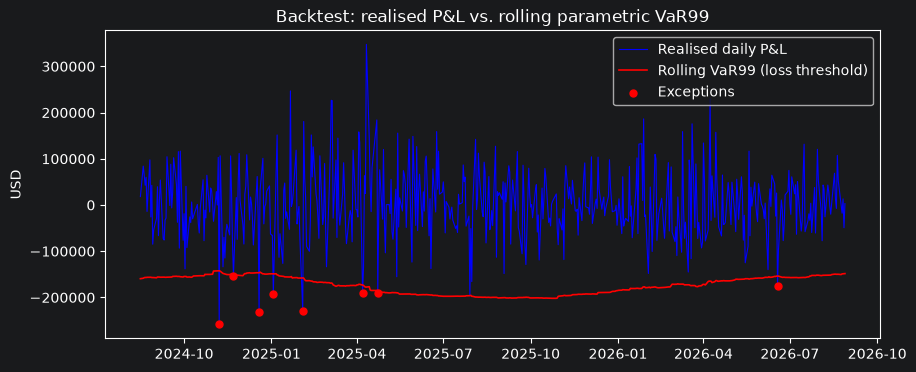

In [13]:
fig, ax = plt.subplots()
ax.plot(dates_valid, pnl_valid, color="b", lw=0.8, label="Realised daily P&L")
ax.plot(dates_valid, -var_valid, color="r", lw=1.2, label="Rolling VaR99 (loss threshold)")
ax.scatter(dates_valid[exceptions_mask], pnl_valid[exceptions_mask],
           color="r", zorder=5, s=25, label="Exceptions")
ax.set_title("Backtest: realised P&L vs. rolling parametric VaR99")
ax.set_ylabel("USD")
ax.legend()
plt.show()

## 9. Conclusions and limitations

- Both methods produced closely aligned **1-day 99% VaR** estimates for this exposure book, and the
  backtest did not reject the model's calibration — the observed exception rate was close to the 1% target.
- **Parametric VaR** is fast and simple to compute, but its accuracy hinges entirely on returns being
  (multivariate) normal and the portfolio being linear in the risk factors. FX returns in practice show
  **fatter tails** than the normal distribution (especially around central bank announcements or de-pegs),
  so parametric VaR tends to **understate tail risk**.
- **Monte Carlo** solves the same problem here, but its real advantage appears once the book contains
  **non-linear instruments** (FX options, as used for hedging) or the analyst wants to simulate from a
  fatter-tailed distribution (e.g. Student-t) or historical bootstrap — none of which have a simple closed
  form.
- Neither method here says anything about **how bad the loss is beyond the VaR threshold** — that is what
  **Expected Shortfall / CVaR** is for, a natural next step.
- A third classic approach, **Historical Simulation** (using actual historical returns instead of a
  parametric or simulated distribution), makes no distributional assumption at all and is worth mentioning
  as a complement, though not implemented here.
- For a Treasury/ALM function, VaR is one input among several: it should sit alongside **stress testing**
  (specific adverse scenarios, e.g. a 10% EUR devaluation), **sensitivity/exposure limits**, and the actual
  **hedging decision** (which forwards/options to trade, and how much of the exposure to cover) that this
  risk measure is ultimately meant to inform.